In [1]:
import pandapower.networks as pn
import pandapower as pp
import pandas as pd
import numpy as np
import openpyxl
import pandapower.plotting as pplt
import matplotlib.pyplot as plt
from copy import deepcopy
import math

load_data=pd.read_excel('daily_load.xlsx') 
net = pn.create_cigre_network_mv(with_der=False) # Create predefined network from standard CIGRE MV test case

In [2]:
# Create buses, transformers and lines
pp.create_bus(net, name='Bus_1', vn_kv=0.4, type='b', geodata=((3,14)))
pp.create_bus(net, name='Bus_2', vn_kv=0.4, type='b', geodata=((3,12)))
pp.create_bus(net, name='Bus_3', vn_kv=0.4, type='b', geodata=((3,10)))
pp.create_bus(net, name='Bus_4', vn_kv=0.4, type='b', geodata=((1.5,8)))
pp.create_bus(net, name='Bus_5', vn_kv=0.4, type='b', geodata=((0,6)))

pp.create_transformer(net, hv_bus=1, lv_bus=pp.get_element_index(net,'bus','Bus_1'),name='L1', std_type='0.63 MVA 20/0.4 kV')
pp.create_transformer(net, hv_bus=2, lv_bus=pp.get_element_index(net,'bus','Bus_2'),name='L2', std_type='0.25 MVA 20/0.4 kV')
pp.create_transformer(net, hv_bus=3, lv_bus=pp.get_element_index(net,'bus','Bus_3'),name='L3', std_type='0.25 MVA 20/0.4 kV')
pp.create_transformer(net, hv_bus=4, lv_bus=pp.get_element_index(net,'bus','Bus_4'),name='L4', std_type='0.25 MVA 20/0.4 kV')
pp.create_transformer(net, hv_bus=5, lv_bus=pp.get_element_index(net,'bus','Bus_5'),name='L5', std_type='0.25 MVA 20/0.4 kV')


np.int64(6)

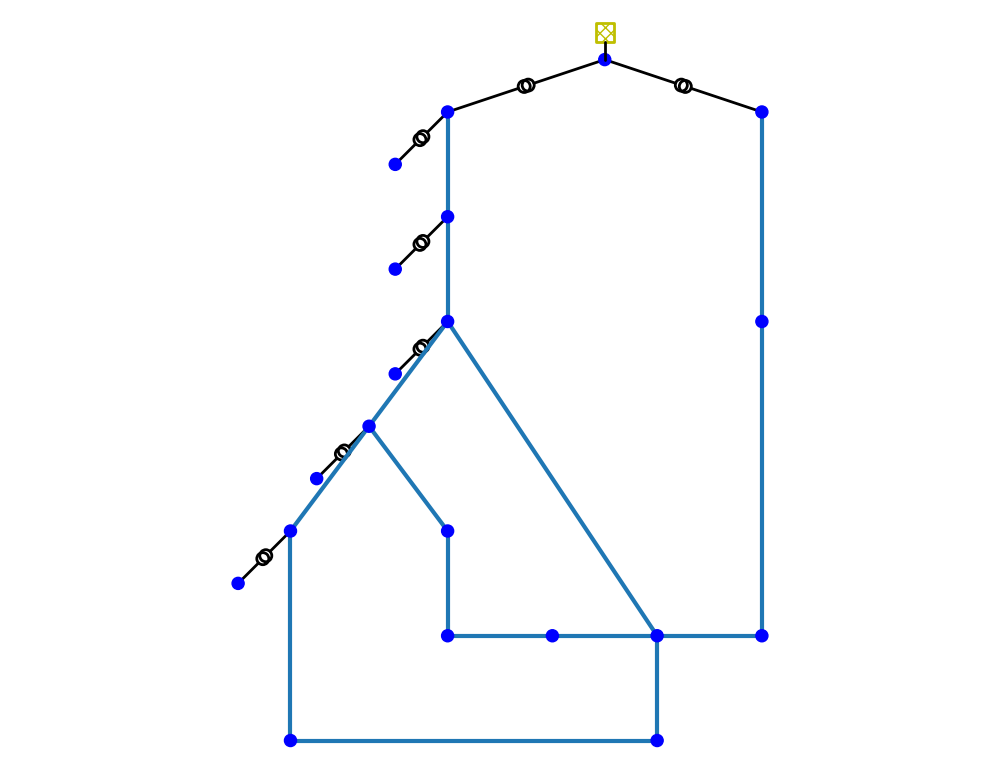

In [3]:
# Plot the network
ax=pplt.simple_plot(net,show_plot=False)
clc = pplt.create_line_collection(net, linewidth=3, use_bus_geodata=True)
pplt.draw_collections([clc], ax=ax)
plt.show()

In [4]:
# Run power flow calculation
pp.runpp(net, numba=False)

net.res_trafo

,p_hv_mw,q_hv_mvar,p_lv_mw,q_lv_mvar,pl_mw,ql_mvar,i_hv_ka,i_lv_ka,vm_hv_pu,va_hv_degree,vm_lv_pu,va_lv_degree,loading_percent
0,24.433763,9.228284e+00,-2.439261e+01,-6.141832e+00,0.041153,3.086452e+00,0.133093,7.320124e-01,1.030000,0.000000,0.991967,-36.558070,101.430618
1,20.616666,7.114643e+00,-2.058797e+01,-4.962515e+00,0.028695,2.152128e+00,0.111137,6.112555e-01,1.030000,0.000000,1.000146,-35.487100,84.698048
2,0.001624,1.249609e-07,3.702408e-15,1.347755e-15,0.001624,1.249609e-07,0.000047,5.733167e-15,0.991967,-36.558070,0.991951,173.437520,0.259797
3,0.000750,6.987570e-08,5.326723e-16,-7.118438e-17,0.000750,6.987570e-08,0.000022,8.012345e-16,0.968130,-37.606361,0.968108,172.388300,0.309794
4,0.000693,6.460890e-08,4.428175e-16,-4.917884e-16,0.000693,6.460890e-08,0.000021,1.026081e-15,0.930929,-39.334259,0.930908,170.660402,0.297891
5,0.000691,6.435044e-08,2.715962e-16,-8.816691e-16,0.000691,6.435044e-08,0.000021,1.433292e-15,0.929065,-39.438379,0.929044,170.556282,0.297294
6,0.000689,6.417376e-08,3.717068e-16,-8.978244e-16,0.000689,6.417376e-08,0.000021,1.511766e-15,0.927789,-39.510078,0.927768,170.484582,0.296886


In [5]:
# Calculate time series for loads
p_mw_series = []
q_mvar_series = []

for index, load in net.load.iterrows():
   
    hourly_time = load_data['hour']  
    load_factor = load_data['loadshape']

    
    new_p_mw = load['p_mw']* load_factor
    new_q_mvar = load['q_mvar']*load_factor
    

    
    p_mw_series.append(new_p_mw)
    q_mvar_series.append(new_q_mvar) 
    

net.load['p_mw_series'] = p_mw_series
net.load['q_mvar_series'] = q_mvar_series



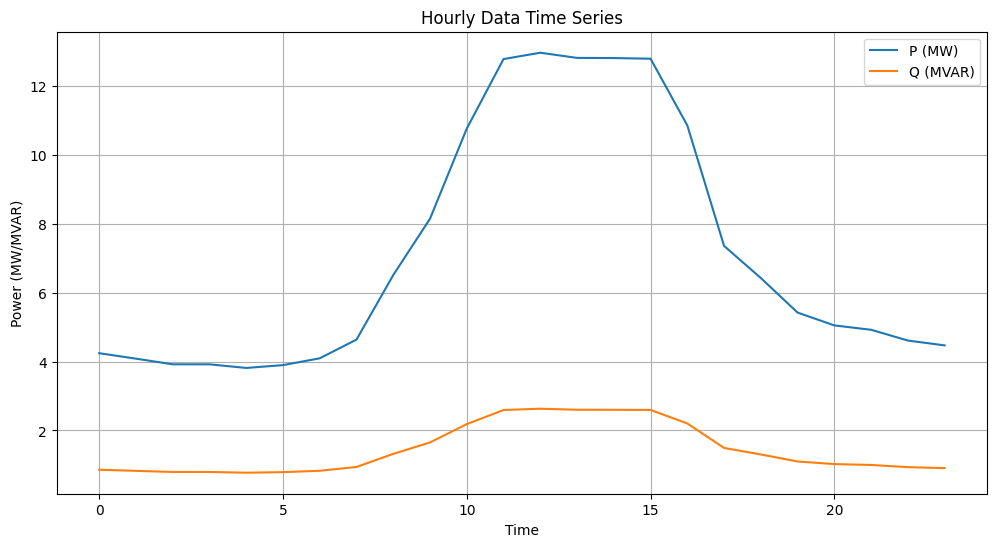

In [6]:
#Plot the data
plt.figure(figsize=(12, 6))
plt.plot(hourly_time, net.load.loc[0,'p_mw_series'], label='P (MW)')
plt.plot(hourly_time, net.load.loc[0,'q_mvar_series'], label='Q (MVAR)')
plt.xlabel('Time')
plt.ylabel('Power (MW/MVAR)')
plt.title('Hourly Data Time Series')
plt.legend()
plt.grid()
plt.show()


In [7]:
# Run new powerflow for a specific load
pp.runpp(net, numba=False)

net.load.loc[8] 

name                                                          Load R12
bus                                                                 12
p_mw                                                            14.994
q_mvar                                                        3.044662
const_z_p_percent                                                  0.0
const_i_p_percent                                                  0.0
const_z_q_percent                                                  0.0
const_i_q_percent                                                  0.0
sn_mva                                                            15.3
scaling                                                            1.0
in_service                                                        True
type                                                               wye
p_mw_series          0      4.241053
1      4.082791
2      3.91917...
q_mvar_series        0     0.861183
1     0.829046
2     0.795822
3...
Name: 

In [8]:
# Individual bus results
net.res_bus

,vm_pu,va_degree,p_mw,q_mvar
0,1.030000,0.000000,-45.050429,-16.342928
1,0.991967,-36.558070,19.839000,4.637136
2,0.968130,-37.606361,0.000000,0.000000
3,0.930929,-39.334259,0.501700,0.208882
4,0.929065,-39.438379,0.431650,0.108182
5,0.927789,-39.510078,0.727500,0.182329
6,0.926287,-39.595253,0.548050,0.137354
7,0.925090,-39.592876,0.076500,0.047410
8,0.925372,-39.582307,0.586850,0.147078
9,0.924390,-39.622485,0.573750,0.355578
